In [ ]:
#data preview

import pandas as pd

df= pd.read_csv("BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
#data summery

df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [ ]:
df.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


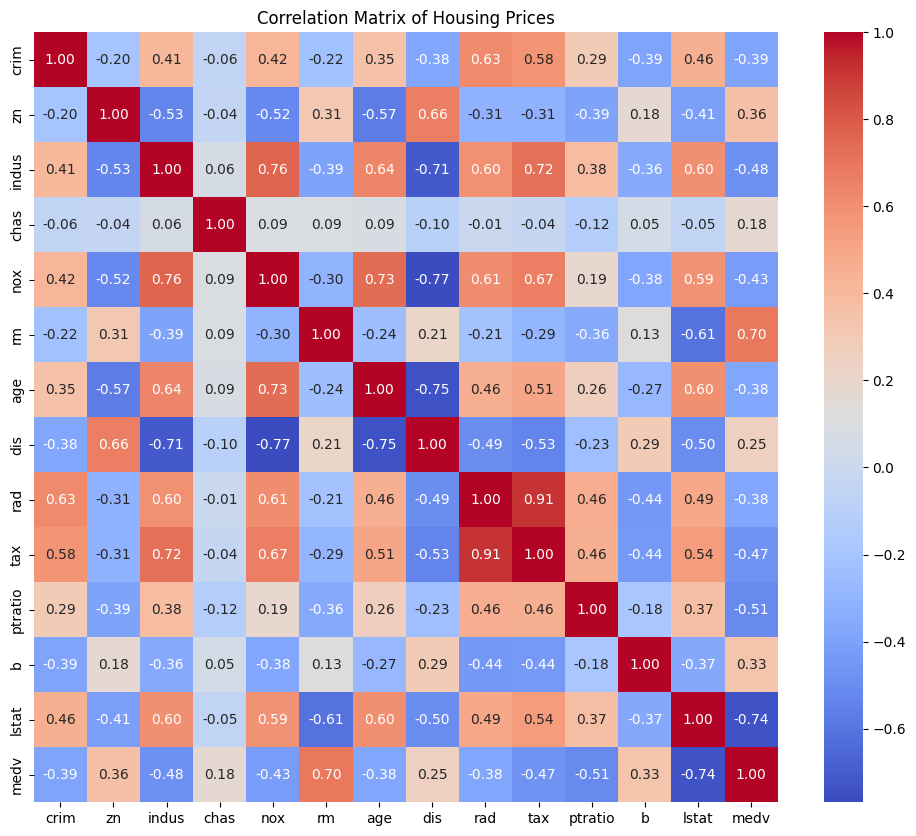

In [12]:
#correlation matrix

import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Housing Prices')
plt.show()


In [13]:
'''
correlation analysis:
strong negetive corelation:Pupil-teacher ratio by town(ptratio),	% lower status of the population(lstat)

strong positive corelation:Average number of rooms per dwelling(rm)



In [19]:
#binning continous data

df["ptratio_binned"] = pd.cut(df["ptratio"], bins=[0, 35, 70, 100], labels=["low", "Middle", "high"])
df["lstat_binned"] = pd.cut(df["lstat"], bins=[0, 35, 70, 100], labels=["low", "Middle", "high"])



In [27]:
#checking the skeweness


# Select only numerical columns for skewness calculation
numerical_df = df.select_dtypes(include=['number'])

# Calculate skewness for numerical columns
skewness = numerical_df.skew()

print(skewness)

crim        5.223149
zn          2.225666
indus       0.295022
chas        3.405904
nox         0.729308
rm          0.403612
age        -0.598963
dis         1.011781
rad         1.004815
tax         0.669956
ptratio    -0.802325
b          -2.890374
lstat       0.906460
medv        1.108098
crim_log    1.269201
dtype: float64


In [30]:
'''
ptratio, lstat, and rm are moderately skewed
i'm gonna log the rm and lstat since they are more important
'''

"\nptratio, lstat, and rm are moderately skewed\ni'm gonna log the rm and lstat since they are more important\n"

In [31]:
#logging skewed but important data

import numpy as np

df['rm_log'] = np.log1p(df['rm'])

df['lstat_log'] = np.log1p(df['lstat'])


In [33]:
#standardizing data(Normalize values so features are on a similar scale)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_cols = ["rm", "lstat", "ptratio", "medv"]
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])


In [43]:
# save the model

import pickle

# Assuming 'model' is your trained linear regression model
# Save the model to a file
filename = 'boston_housing_model.sav'
pickle.dump(model, open(filename, 'wb'))


In [45]:
# random forest model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

# Load the dataset
df = pd.read_csv("BostonHousing.csv")

# Feature engineering (log transformation)
df['rm_log'] = np.log1p(df['rm'])
df['lstat_log'] = np.log1p(df['lstat'])

# Standardize data
scaler = StandardScaler()
scaled_cols = ["rm", "lstat", "ptratio", "medv"]
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

# Define features and target variable
X = df[['rm_log', 'lstat_log', 'ptratio']]
y = df['medv']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42) # You can tune hyperparameters
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Save the model
filename = 'boston_housing_randomforest_model.sav'
pickle.dump(model, open(filename, 'wb'))


Mean Squared Error: 0.22578744789885752
R-squared: 0.7400805561117194


In [44]:
#MSE=0.22 , RMSE=0.46 which means average error of 460$ in prediction of house prices